# Load intro stuff

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packa

In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
# VLA k band 9 mm (ish)
all_bands    = ["Band 4 nterms2",  "Band 5", "Band 5 robust -1",     "Band 6", "Band 7 nterms2"]
bands_naming = ['Band4_nterms2',   'Band5',  "Band5_robust_minus1",  'Band6',  'Band7_nterms2']
bands_labels = ['Band 4',          'Band 5', "Band 5 robust -1",      'Band 6', 'Band 7']

In [4]:
df_POLF = load_POLF(all_bands, print_things = True)

Band = Band 4 nterms2
Band = Band 5
Band = Band 5 robust -1
Band = Band 6
Band = Band 7 nterms2
 in load_POLF, results = {'Band': ['Band 4 nterms2', 'Band 5', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2'], 'POLF_Gaussian': [1.1877280000000001, 0.9329613999999999, 1.3769860999999999, 1.4453122, 0.8302132], 'POLF_maxPOLI': [1.561384, 1.0520775, 1.5137895000000001, 1.4862873, 1.0841521], 'POLF_maxStokesI': [1.3677061000000001, 0.9908963, 1.4034492, 1.4639224, 1.0421403]}


In [5]:
df_POLF

,Band,POLF_Gaussian,POLF_maxPOLI,POLF_maxStokesI,POLF_mean
0,Band 4 nterms2,1.187728,1.561384,1.367706,1.372273
1,Band 5,0.932961,1.052077,0.990896,0.991978
2,Band 5 robust -1,1.376986,1.513790,1.403449,1.431408
3,Band 6,1.445312,1.486287,1.463922,1.465174
4,Band 7 nterms2,0.830213,1.084152,1.042140,0.985502


In [6]:


# --------------------------------------------------------------------------------------
def plot_scale_factor_results(bands,        # These are the bands we are looking at
                              bands_labels, 
                              bands_included_in_fit, # These are the values that were fit
                              f_values,     # These are the porosity values we are testing
                              a_max_times_f_dist_micron,
                              P_times_omega,
                              sf,           # This is the values the data is being scaled by 
                              best_idx, 
                              best_a_max_times_f,        # These are the best a_max values for each f
                              POLF_markers,    # These are the values for each band we are plotting the marker at
                              plot_sf = 1.5, # This controls how much the text labels are scaled by
                              ymin = -0.1, 
                              ymax = 1.7, 
#                               hlines = False,
                              custom_lw = None,
                              custom_text_x = None,
                             chi_sq_precision = 3,
                             x_axis = 'amax_f',
                              fig_x = 30, fig_y = 8,
                             for_poster = False,
                            f_fs = 45, 
                            f_x = 0.05, f_y = 0.9,
                             spine_width = 1):
    band_ls = [
    '-' if b in bands_included_in_fit else '--'
    for b in bands
    ]
    
#     if custom_lw is None:
#         # default behavior
#         bands_lw = [
#             5 if b in bands_included_in_fit else 3
#             for b in bands
#         ]
#     else:
#         # override where specified
#         bands_lw = [
#             custom_lw.get(b, 5 if b in bands_included_in_fit else 3)
#             for b in bands
#         ]
    # Set default line widths
    # ------------------------------------------------
    if for_poster:
        included_lw = poster_lw
    else:
        included_lw = 5

    excluded_lw = included_lw * (2/3)

    if custom_lw is None:
        bands_lw = [
            included_lw if b in bands_included_in_fit else excluded_lw
            for b in bands
        ]
    else:
        bands_lw = [
            custom_lw.get(
                b,
                included_lw if b in bands_included_in_fit else excluded_lw
            )
            for b in bands
        ]
    # ------------------------------------------------
        
    # Change sizes of things if for_poster or not
    # ---------------------------
    if for_poster:
        num_fs = poster_axis_num_fs
        xy_axis_fs = poster_axis_label_fs 
        stats_fs = poster_text2_fs
        legend_marker_size = poster_colour_bands_legend_ms
        band_legend_fs = poster_colour_bands_fs
        marker_size = poster_colour_bands_ms
    # ---------------------------
    else: 
        num_fs = axis_num_fs*plot_sf
        xy_axis_fs = axis_label_fs * plot_sf
        stats_fs = 30
        legend_marker_size = 20
        band_legend_fs = 30
        marker_size = 400
    # ---------------------------
    
    # Set the colors and marker size for each band 
    band_colors = []
    ms = []

    for b in bands:
        if for_poster and b == "Band 5 robust -1":
            band_colors.append(alma_band_colors["Band 5"])
            ms.append(constants.alma_band_ms["Band 5"])
        else:
            band_colors.append(alma_band_colors[b])
            ms.append(constants.alma_band_ms[b])
    
    
    
    # Make the figure
    # Later I will make this so you can customize how many figures you need
    fig, ax = plt.subplots(1, 4, figsize=(fig_x, fig_y))
    
    
    
    
    # Loop over the f values you want to plot
    for i, f in enumerate(f_values): 
        
        for spine in ax[i].spines.values():
            spine.set_linewidth(spine_width)
        
       

        if i == 0:
            ax[i].set_ylabel('P $\omega$', fontsize = xy_axis_fs)
        else:
            ax[i].set_yticklabels([])
            ax[i].set_ylabel('')
            ax[i].tick_params(left=False)

        # Make the x-axis log scale 
        ax[i].set_xscale("log")


    
        # x-axis label
        if x_axis == 'amax_f':
            ax[i].set_xlabel(r'$a_{\mathrm{max}} f / \mu\mathrm{m}$', fontsize = xy_axis_fs)
            
        elif x_axis == 'amax':
            ax[i].set_xlabel(r'$a_{\mathrm{max}}  [\mu\mathrm{m}]$', fontsize = xy_axis_fs)
            
            if for_poster:
                ax[i].set_xlabel('Maximum grain size [$\mu$m]', fontsize = xy_axis_fs)
    
        # Set ticks
        ax[i].minorticks_on()
        ax[i].tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4, width=spine_width)
        ax[i].tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4, width=spine_width)
        
        
        # Control the font size of the numbers on the axes
        # ---------------------------------------------------------------------------------------
            
        ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize = num_fs, width=spine_width)
        ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize = num_fs, width=spine_width)
        # ---------------------------------------------------------------------------------------
        
        
        # ---------------------------------------------------------------------------------------
        # ---------------------------------------------------------------------------------------

        # f labels on plot
        # ---------------------------------------------------------------------------------------
        if for_poster == False:
            ax[i].set_title(f'$f$ = {f:.2f}', fontsize=50)
            
        else:
            ax[i].text(f_x, f_y,  f'$f$ = {f:.2f}', transform=ax[i].transAxes, fontsize = poster_text1_fs)
            
        
#         if for_poster == True:
#             ax[i].text(x_pos, 0.15,  f'$\chi^2$ = {chi_sq:.{chi_sq_precision}f}', transform=ax[i].transAxes, fontsize = 30)
        # ---------------------------------------------------------------------------------------

        ax[i].set_ylim(ymin, ymax)
        # ------------------------------------------
        
        
        marker_handles = []
        # plot each band for this f
        for j, b in enumerate(bands):
            
            idx = bands.index(b)
            
            
#             print(rf'At band {b}, the POLF_obs value is: {POLF_obs[f][idx]}')
#             print(' ')

            fc = band_colors[j]
            ec = band_colors[j]
            marker_lw = 0 

            if for_poster and b == "Band 5 robust -1":
                fc = alma_band_colors["Band 5"]
                ec = alma_band_colors["Band 5"]

            if b == "Band 5" and not for_poster:
                fc = 'none'
                marker_lw = 5

            # Pick the x-axis location for the markers based on the type of plot
            # ---------------------------------------------------------------------
            # Note: a_max is actually a_max * f
            # ---------------------------------------------------------------------
            if x_axis == 'amax_f':
                xloc_marker = best_a_max_times_f[f]
            # ---------------------------------------------------------------------
            elif x_axis == 'amax':
                xloc_marker = best_a_max_times_f[f] / f
            # ---------------------------------------------------------------------
            # Plot the POLF markers
            plot_marker = True

            if for_poster and b == "Band 5":
                plot_marker = False

            if plot_marker:
                ax[i].scatter(
                    xloc_marker, 
                    POLF_markers[b],
                    marker=ms[j], 
                    s=marker_size,
                    facecolors=fc,
                    edgecolors=ec,
                    linewidths=marker_lw
                )
            # ---------------------------------------------------------------------

        
            marker_handles.append(
            Line2D([0], [0],
                   marker=ms[j],
                   color='none',
                   markerfacecolor=fc,
                   markeredgecolor=ec,
                   markeredgewidth=marker_lw,
                   markersize=15,
                   linestyle='None'))

            if b not in ["Band 5 robust -1", "Band 5 robust -2"]:
                
                if x_axis == 'amax_f':
                    ax[i].plot(a_max_times_f_dist_micron[f],
                               P_times_omega[f][:, idx] * sf[f],
                               color=band_colors[j],
                               label=b,
                               lw=bands_lw[j],
                               ls=band_ls[j])
                
                elif x_axis == 'amax':
                    ax[i].plot(a_max_times_f_dist_micron[f] / f,
                                   P_times_omega[f][:, idx] * sf[f],
                                   color=band_colors[j],
                                   label=b,
                                   lw=bands_lw[j],
                                   ls=band_ls[j])

        # Calculate chi_sq
        # ---------------------------------------------
        # ---------------------------------------------
        chi_sq_running_sum = 0
        chi_sq = 0
        
        #print('In chi squared calculation:')
        #print(rf'f = {f}')
        #print(rf'best_idx = {best_idx[f]}')
#         print(rf'The best_index is {best_idx[f]}')
        # Loop over each band 
        for j, b in enumerate(bands):
            
            if b == "Band 5":
                continue
            
            band_idx = bands.index(b)
            
            
            POLF_obs = POLF_markers[b]
            POLF_model = P_times_omega[f][best_idx[f], band_idx] * sf[f]
            
            chi_sq_running_sum = chi_sq_running_sum + (POLF_obs - POLF_model)**2
            
            
            #print(rf'At band {bf}, or index {band_idx}:')
            #print(rf'   the observed POLF is {POLF_obs:.2f}, and the measured POLF is {POLF_model:.2f} and the difference = {(POLF_obs - POLF_model):.2f}')
        chi_sq = chi_sq_running_sum
        #print(' ')
        # ---------------------------------------------
        # ---------------------------------------------
        
        
        
                
        x_pos = 0.05 
        
        if custom_text_x is not None:
            x_pos = x_pos + custom_text_x[i]
        
        
        
        ax[i].text(x_pos, 0.15,  f'$\chi^2$ = {chi_sq:.{chi_sq_precision}f}', transform=ax[i].transAxes, fontsize = stats_fs)

        # Only add sf if for_poster = False
        if for_poster == False:
            ax[i].text(x_pos, 0.25, f'sf = {sf[f]:.2f}', transform=ax[i].transAxes, fontsize = stats_fs)


        # Add the a_max to the text
        best_amax_text = best_a_max_times_f[f] / f
        ax[i].text(x_pos, 0.05, rf'$a_{{\mathrm{{max}}}}$ = {best_amax_text:.0f} $\mu$m', 
                   transform=ax[i].transAxes, 
                   fontsize = stats_fs)
        
        
        
    #plt.tight_layout()
    
    plt.subplots_adjust(
        left=0.05,
        right=0.98,
        bottom=0.15,
        top=0.95,
        wspace=0.02
    )
    
    
    # Add coloured text for each Band in the far right plot
    # ----------------------------------------------------
    # ----------------------------------------------------
    start = 0.9 # This is the starting vertical position
    c = 0
    marker_legend_handles = []
    
    # Choose legend entries
    if for_poster:
        legend_bands = ["Band 4", "Band 5 robust -1", "Band 6", "Band 7"]
    else:
        legend_bands = bands_labels

    # Loop over legend entries
    for b_label in legend_bands:

        if for_poster and b_label == "Band 5 robust -1":
            label = "Band 5"
            color = alma_band_colors["Band 5"]
            marker = constants.alma_band_ms["Band 5"]

        else:
            label = b_label
            color = alma_band_colors[b_label]
            marker = constants.alma_band_ms[b_label]

        handle = Line2D(
            [0], [0],
            marker=marker,
            color='none',
            markerfacecolor=color,
            markeredgecolor=color,
            markersize=legend_marker_size,
            linestyle='None',
            label=label
        )

        marker_legend_handles.append(handle)
        
        
        
    legend_elements = [
        Line2D([0], [0], color='black', linestyle='-', lw = 5, label='Included'),
        Line2D([0], [0], color='black', linestyle='--', lw = 5, label='Excluded')
    ]
    # ----------------------------------------------------
    # ----------------------------------------------------
        
    legend = ax[3].legend(
            handles=marker_legend_handles,
            fontsize= band_legend_fs,
            frameon=False,
            loc='upper right',
            handletextpad=0.5, # Cotrols distance between marker and text 
            handlelength=1, # Cotrols distance between marker and text 
            labelspacing=0.6 # Controls vertical gap between the markers
        )
    
    if for_poster:
        legend_colors = [
            alma_band_colors["Band 4"],
            alma_band_colors["Band 5"],
            alma_band_colors["Band 6"],
            alma_band_colors["Band 7"]
        ]
    else:
        legend_colors = band_colors

    for text, color in zip(legend.get_texts(), legend_colors):
        text.set_color(color)
#     # ----------------------------------------------------
#     # ----------------------------------------------------



# 

    return fig, ax
    

# --------------------------------------------------------------------------------------

# Choose porosity values we want to test

In [7]:
# These are the porosity values we are going to look at
# all_f_values = [1, 0.75, 0.5, 0.3, 0.25, 0.1, 0.01]

In [8]:
csv_files = {
    1:   "P_omega_vs_amax_f_1_CustomBounds.csv",
    0.75:   "P_omega_vs_amax_f_0_75_CustomBounds.csv",
    0.5:   "P_omega_vs_amax_f_0_5_CustomBounds.csv",
    0.25:   "P_omega_vs_amax_f_0_25_CustomBounds.csv",
    0.3: "P_omega_vs_amax_f_0_3_CustomBounds.csv",
    0.1: "P_omega_vs_amax_f_0_1_CustomBounds.csv",
#     0.01:"P_omega_vs_amax_f_0_01_CustomBounds.csv"
}

# Find the scaling factor

In [9]:
# def find_sf_v2(a_max_f_dist_micron, P_times_omega, df_POLF, print_results=False):

#     # We are looking at the POLF from the mean/average method, none others 
#     POLF_obs = df_POLF['POLF_Gaussian']

#     # Make arrays to store the median and standard deviation values 
#     sf_medians = []
#     sf_stds = []

#     # Loop over each a_max grid point
#     for i in range(len(a_max_f_dist_micron)):

#         Pw_model = P_times_omega[i, :]  # 4 bands
        
#         # Avoid divide by zero
#         valid = Pw_model > 0
        
#         sf_i = POLF_obs[valid] / Pw_model[valid]

#         sf_medians.append(np.median(sf_i))
#         sf_stds.append(np.std(sf_i))

#     sf_medians = np.array(sf_medians)
#     sf_stds = np.array(sf_stds)

#     # Choose best a_max where scatter is minimized
#     best_idx = np.argmin(sf_stds)

#     best_a_max_f = a_max_f_dist_micron[best_idx]
#     best_sf = sf_medians[best_idx]

#     # Compute predicted POLF at best solution
# #     best_POLF = P_times_omega[best_idx, :] * best_sf

#     if print_results:
#         print("Best a_max:", best_a_max_f)
#         print("Best SF:", best_sf)

#     # return values
#     return best_a_max_f, POLF_obs, best_sf


In [10]:
df_POLF

,Band,POLF_Gaussian,POLF_maxPOLI,POLF_maxStokesI,POLF_mean
0,Band 4 nterms2,1.187728,1.561384,1.367706,1.372273
1,Band 5,0.932961,1.052077,0.990896,0.991978
2,Band 5 robust -1,1.376986,1.513790,1.403449,1.431408
3,Band 6,1.445312,1.486287,1.463922,1.465174
4,Band 7 nterms2,0.830213,1.084152,1.042140,0.985502


In [11]:
POLF_type = 'max Stokes I'
plot_sf = 1.5

POLF_obs_for_plot = dict(zip(df_POLF["Band"], df_POLF["POLF_maxStokesI"]))
POLF_obs_for_plot

{'Band 4 nterms2': 1.3677061000000001,
 'Band 5': 0.9908963,
 'Band 5 robust -1': 1.4034492,
 'Band 6': 1.4639224,
 'Band 7 nterms2': 1.0421403}

In [12]:
# # Storage dicts
# a_max_f_dist_micron = {}
# P_times_omega = {}
# best_a_max_f = {}
# POLF_obs = {}
# best_sf = {}
# best_idx = {}

# # Loop through each f value
# for f, fname in csv_files.items():
# #     print("Loading file:", P_omega_data_folder_path + fname)
#     df = pd.read_csv(P_omega_data_folder_path + fname)
# #     print("Columns:", df.columns)


#     df = pd.read_csv(P_omega_data_folder_path + fname)

#     # x-axis (grain sizes in micron)
#     a_max_f_dist_micron[f] = df["a_max_f_micron"].values

#     # y-values (P*omega for each band)
#     P_times_omega[f] = np.column_stack([df[f"P_times_omega_{b}"].values for b in bands_naming])

#     # run best_sf calculation per f
#     best_a_max_f[f], POLF_obs[f], best_sf[f], best_idx[f] = find_sf_v2(
#         a_max_f_dist_micron[f], P_times_omega[f], df_POLF, POLF_type, print_results=False
#     )

# Plot for one porosity value

In [13]:
# band_colors = [alma_band_colors[b] for b in all_bands]
# ms = [alma_band_ms[b] for b in bands]

# f_plot = 0.25

# fig, ax = plot_a_vs_POLF(a_max_f_dist_micron[f_plot], 
#                          P_times_omega[f_plot], 
#                          best_sf[f_plot], 
#                          bands, 
#                          y_plot = 'af', 
#                          legend = 'w sf')

# ax.text(0.80, 0.90, f'sf = {best_sf[f_plot]:.2f}', transform=ax.transAxes, fontsize = 20)
# ax.text(0.80, 0.80, f'f = {f_plot}', transform=ax.transAxes, fontsize = 20)

# for i in range(len(bands)):
#     ax.scatter(best_a_max_f[f_plot], 
#                POLF_obs[f_plot][i], 
#                c = band_colors[i],
#                marker = ms[i], 
#                s = 200)

# Plot for all porosity values

In [14]:
f_values = [1, 0.75, 0.5, 0.25]

# fig, ax = plot_scale_factor_results(all_bands, 
#                                     bands_labels, 
#                                     f_values,                               
#                                     a_max_f_dist_micron, 
#                                     P_times_omega,
#                                     best_sf, best_a_max_f, POLF_obs)
    

In [15]:
bands_fit = ["Band 4 nterms2",  "Band 5 robust -1", "Band 6", "Band 7 nterms2"]


a_max_times_f_dist_micron_all, P_times_omega_all, best_a_max_times_f_all, POLF_obs_all, best_sf_all, best_idx_all = find_sf_v3(
    all_bands,
    bands_naming,
    bands_fit,
    csv_files,
    P_omega_data_folder_path,
    df_POLF,
    POLF_type,
    print_results = True
)



The Bands we are looking at are: ['Band 4 nterms2', 'Band 5', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
best_idx: 4
Best a_max * f: {1: 150.0700700700701, 0.75: 210.1001001001001, 0.5: 270.1301301301301, 0.25: 430.2102102102102, 0.3: 375.6401692273437, 0.1: 1793.5871743486975}
Best SF: {1: 1.738003720532757, 0.75: 1.6230782024276458, 0.5: 1.5798842024835218, 0.25: 1.520240026576944, 0.3: 1.5160886146019812, 0.1: 1.6269927411812257}


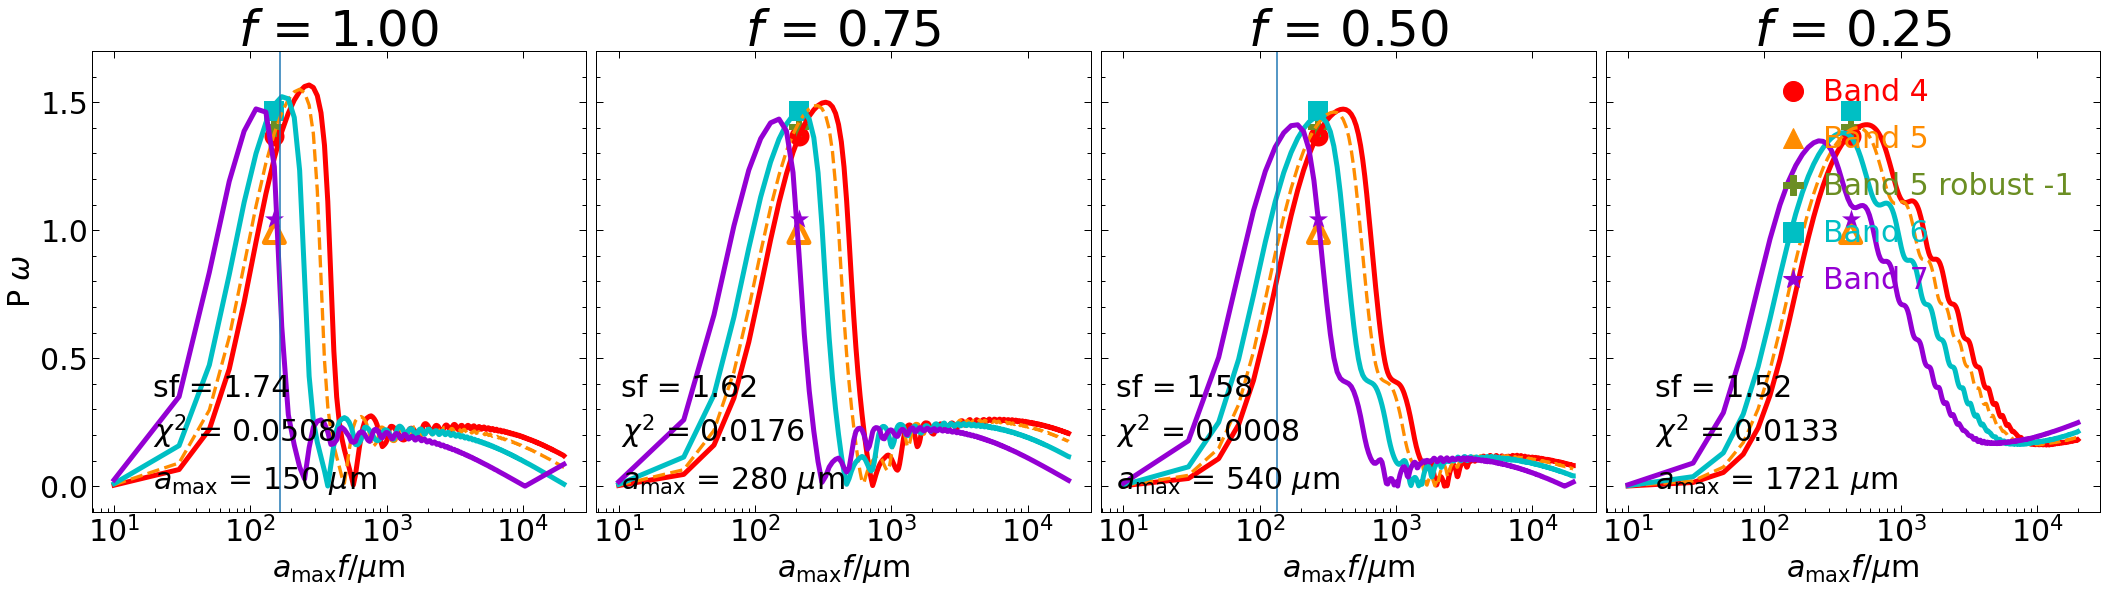

In [16]:
fig, ax = plot_scale_factor_results(all_bands, 
                                    bands_labels, 
                                    bands_fit, 
                                    f_values,                               
                                    a_max_times_f_dist_micron_all, 
                                    P_times_omega_all,
                                    best_sf_all, 
                                    best_idx_all, 
                                    best_a_max_times_f_all, 
                                    POLF_obs_for_plot,
                                    custom_text_x = [0.075, 0, -0.02, 0.05],
                                    chi_sq_precision = 4,
                                    x_axis = 'amax_f')

ax[0].axvline(165)
ax[2].axvline(268 * 0.5) 


# Plot lines so I can see if its correct 
plt.savefig(writeup_image_folder_path + '/DustModels/' + "DustModelPlot_AllBands_amaxf.pdf", 
            dpi=300, 
            bbox_inches='tight')

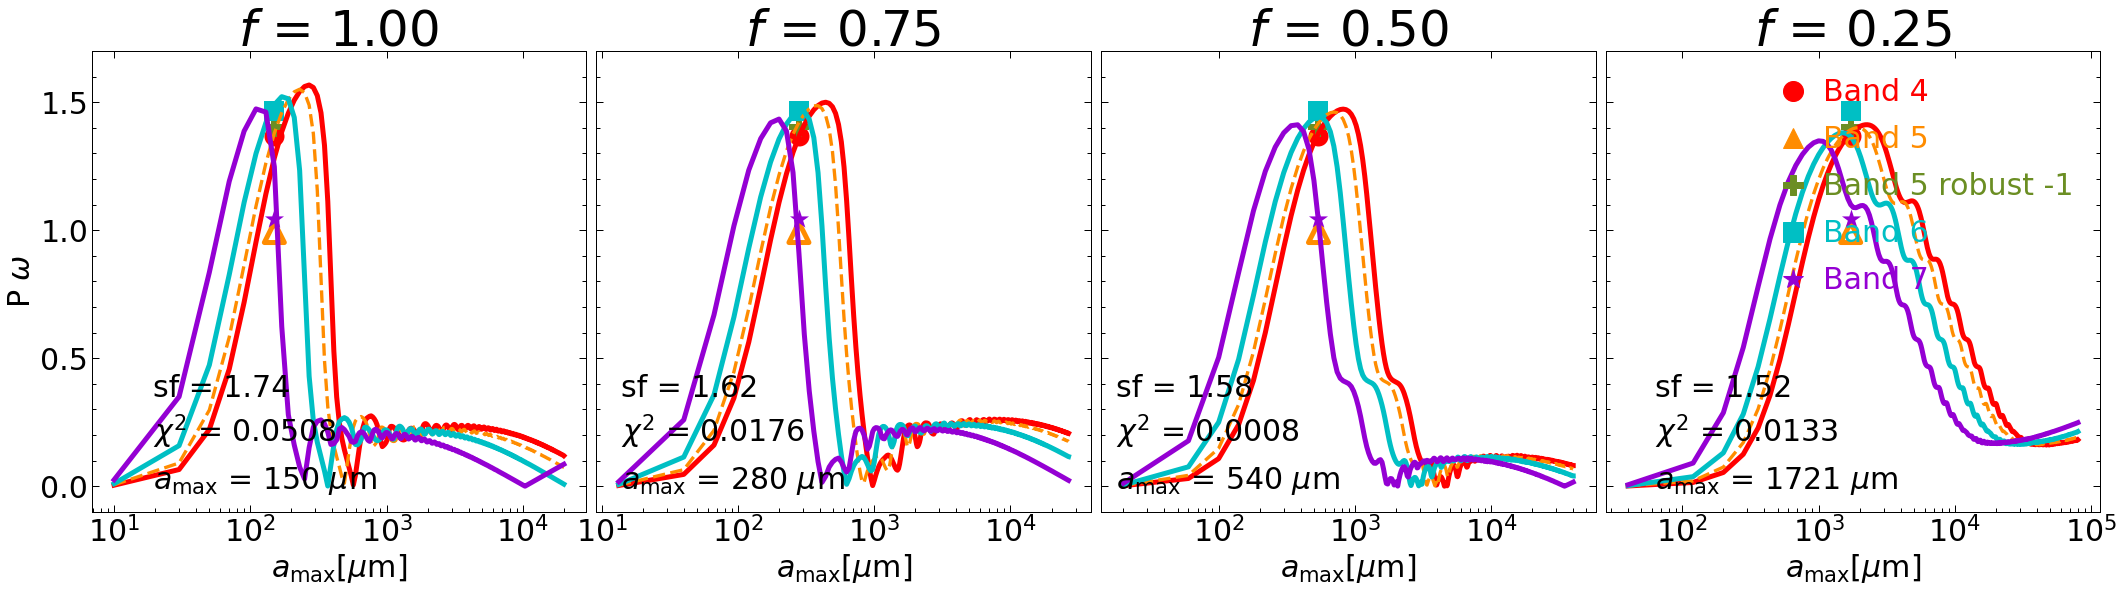

In [17]:
fig, ax = plot_scale_factor_results(all_bands, 
                                    bands_labels, 
                                    bands_fit, 
                                    f_values,                               
                                    a_max_times_f_dist_micron_all, 
                                    P_times_omega_all,
                                    best_sf_all, 
                                    best_idx_all, 
                                    best_a_max_times_f_all, 
                                    POLF_obs_for_plot,
                                    custom_text_x = [0.075, 0, -0.02, 0.05],
                                    chi_sq_precision = 4,
                                    x_axis = 'amax')
# Plot lines so I can see if its correct 
plt.savefig(writeup_image_folder_path + '/DustModels/' + "DustModelPlot_AllBands.pdf", 
            dpi=300, 
            bbox_inches='tight')

Target poster size = (49.8, 12.15) cm
figx, figy = (27.570, 6.727)
(13784, 3363)


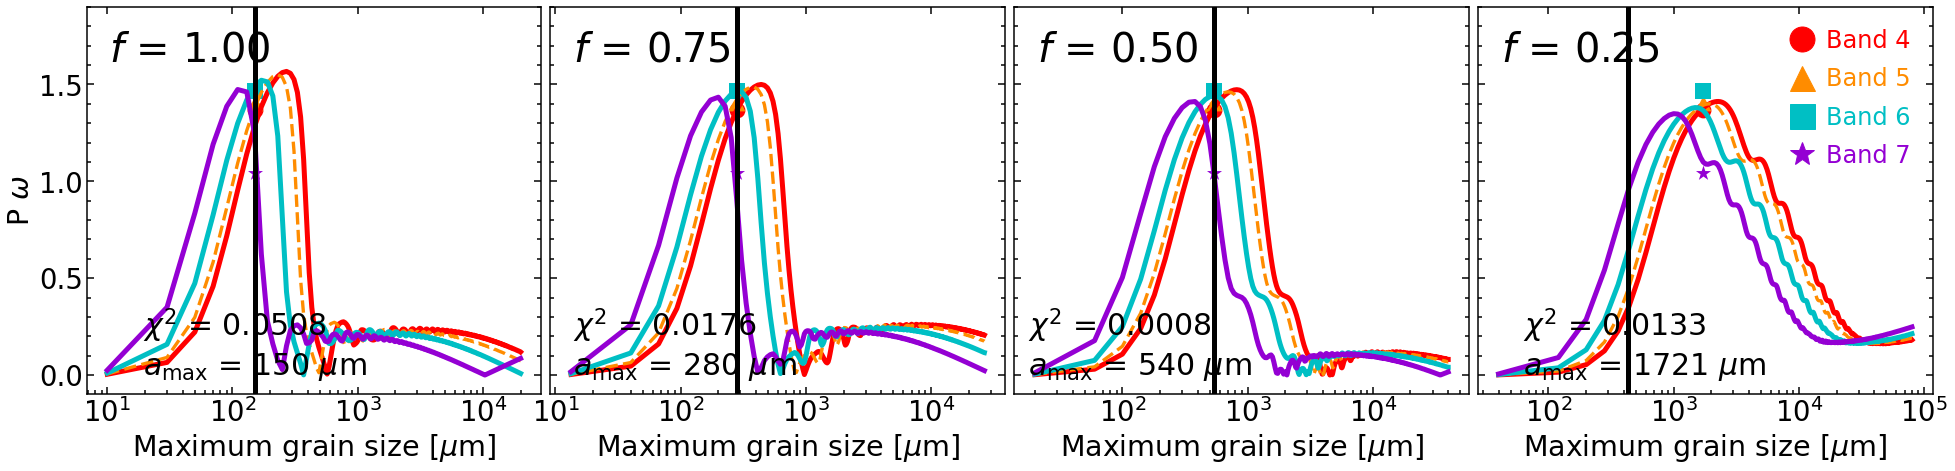

In [31]:
# Desired final size on poster
poster_x_cm = constants.poster_refx
poster_y_cm = constants.poster_refy

print(rf"Target poster size = ({poster_x_cm}, {poster_y_cm}) cm")

# Calibration from your original test
calib_figx = 30
calib_figy = 8

calib_slides_x_cm = 54.19
calib_slides_y_cm = 14.45

# Convert poster size -> matplotlib figsize
figx = calib_figx * poster_x_cm / calib_slides_x_cm
figy = calib_figy * poster_y_cm / calib_slides_y_cm

print(rf"figx, figy = ({figx:.3f}, {figy:.3f})")

poster_bands_labels = ['Band 4',   "Band 5 robust -1",      'Band 6', 'Band 7']

# --------------------------------------------------------------------------------------
fig, ax = plot_scale_factor_results(all_bands, 
                                    bands_labels, 
                                    bands_fit, 
                                    f_values,                               
                                    a_max_times_f_dist_micron_all, 
                                    P_times_omega_all,
                                    best_sf_all, 
                                    best_idx_all, 
                                    best_a_max_times_f_all, 
                                    POLF_obs_for_plot,
                                    custom_text_x = [0.075, 0, -0.02, 0.05],
                                    chi_sq_precision = 4,
                                    x_axis = 'amax',
                                    for_poster = True,
                                  #f_fs = 45, 
                                   # f_x = 0.05, f_y = 0.9,
                                   fig_x = figx, fig_y = figy,
                                   plot_sf = 1,
                                   ymax = 1.9,
                                   f_y = 0.86,
                                   spine_width = poster_spine_width)

# ax[0].axvline(165)
# ax[2].axvline(268)

# Hardcode lines to check
ax[0].axvline(150, lw = 5, color = 'black')
ax[1].axvline(280, lw = 5, color = 'black')
ax[2].axvline(540, lw = 5, color = 'black')
ax[3].axvline(430, lw = 5, color = 'black')

# Plot lines so I can see if its correct 
plt.savefig(image_folder_path + '/POSTER/' + "DustModelPlot_AllBands.png", 
            dpi=500, 
          #  bbox_inches='tight',
               facecolor='white')

from PIL import Image

img = Image.open(image_folder_path + '/POSTER/' + "DustModelPlot_AllBands.png")
print(img.size)

In [19]:
# raise SystemExit("Stop here")

# Fit and Plot without Band 5

In [20]:
bands_wo5 = ["Band 4 nterms2",  "Band 6", "Band 7 nterms2"]


a_max_times_f_dist_micron_wo5, P_times_omega_wo5, best_a_max_times_f_wo5, POLF_obs_wo5, best_sf_wo5, best_idx_wo5 = find_sf_v3(
    all_bands,
    bands_naming,
    bands_wo5,
    csv_files,
    P_omega_data_folder_path,
    df_POLF,
    POLF_type
)



The Bands we are looking at are: ['Band 4 nterms2', 'Band 5', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 6', 'Band 7 nterms2']


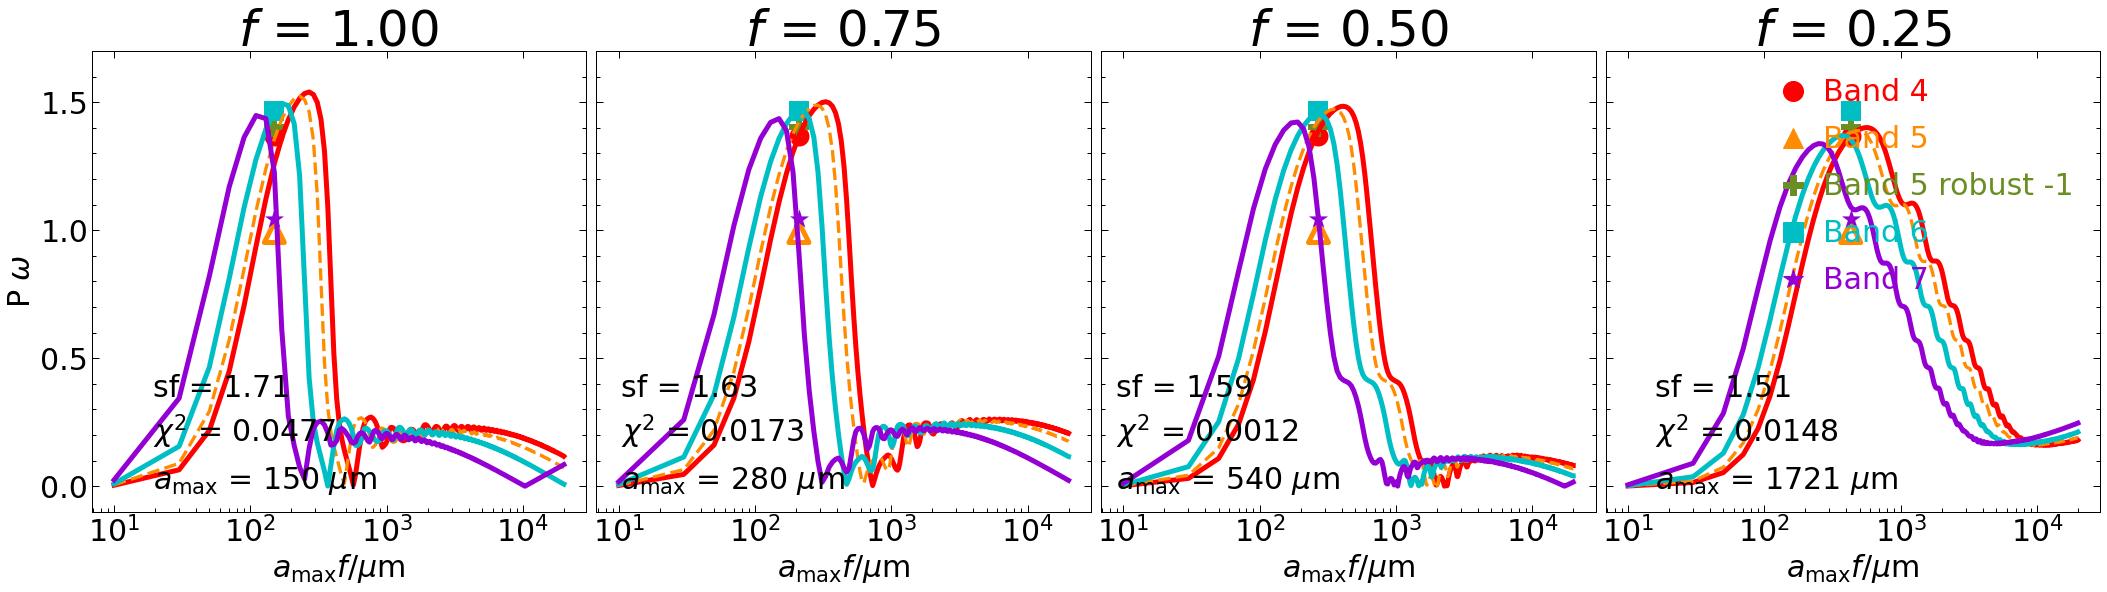

In [21]:
fig, ax = plot_scale_factor_results(all_bands, 
                                    bands_labels, 
                                    bands_wo5, 
                                    f_values,                               
                                    a_max_times_f_dist_micron_wo5, 
                                    P_times_omega_wo5,
                                    best_sf_wo5, 
                                    best_idx_wo5,
                                    best_a_max_times_f_wo5, 
                                    POLF_obs_for_plot,
                                    custom_text_x = [0.075, 0, -0.02, 0.05],
                                   chi_sq_precision = 4,
                                   x_axis = 'amax_f')
    
# Also want to plot Band 5 data 
plt.savefig(writeup_image_folder_path + '/DustModels/' + "DustModelPlot_Without5_amaxf.pdf", 
            dpi=300, 
            bbox_inches='tight')

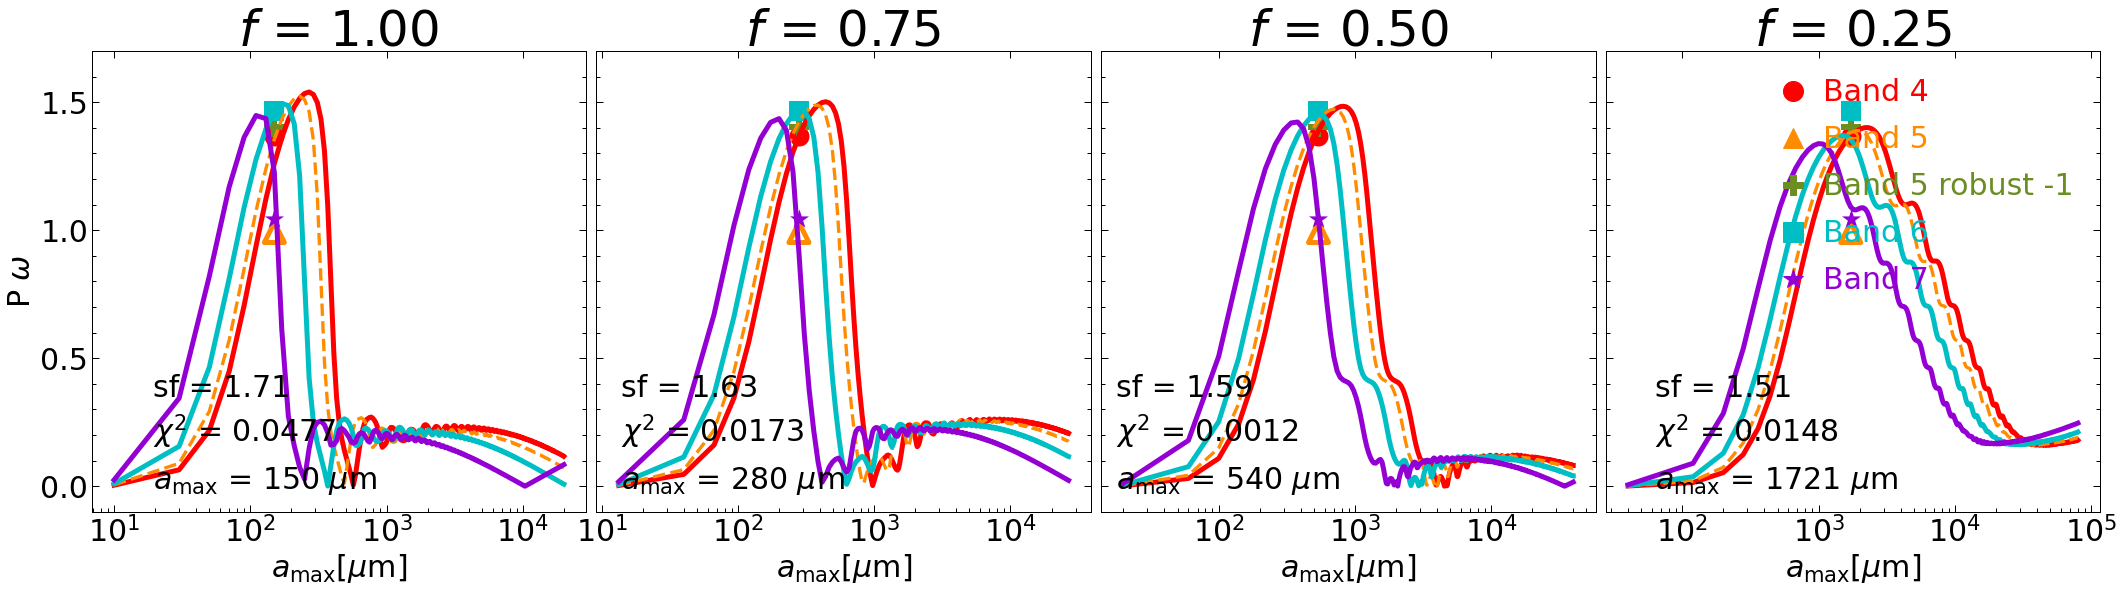

In [22]:
fig, ax = plot_scale_factor_results(all_bands, 
                                    bands_labels, 
                                    bands_wo5, 
                                    f_values,                               
                                    a_max_times_f_dist_micron_wo5, 
                                    P_times_omega_wo5,
                                    best_sf_wo5, 
                                    best_idx_wo5,
                                    best_a_max_times_f_wo5, 
                                    POLF_obs_for_plot,
                                    custom_text_x = [0.075, 0, -0.02, 0.05],
                                   chi_sq_precision = 4,
                                   x_axis = 'amax')
    
# Also want to plot Band 5 data 
plt.savefig(writeup_image_folder_path + '/DustModels/' + "DustModelPlot_Without5.pdf", 
            dpi=300, 
            bbox_inches='tight')

# Fit and plot without 6

In [23]:
bands_wo6 = ["Band 4 nterms2", "Band 5", "Band 5 robust -1",  "Band 7 nterms2"]


a_max_times_f_dist_micron_wo6, P_times_omega_wo6, best_a_max_times_f_wo6, POLF_obs_wo6, best_sf_wo6, best_idx_wo6 = find_sf_v3(
    all_bands,
    bands_naming,
    bands_wo6,
    csv_files,
    P_omega_data_folder_path,
    df_POLF,
    POLF_type
)



The Bands we are looking at are: ['Band 4 nterms2', 'Band 5', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 5', 'Band 5 robust -1', 'Band 7 nterms2']


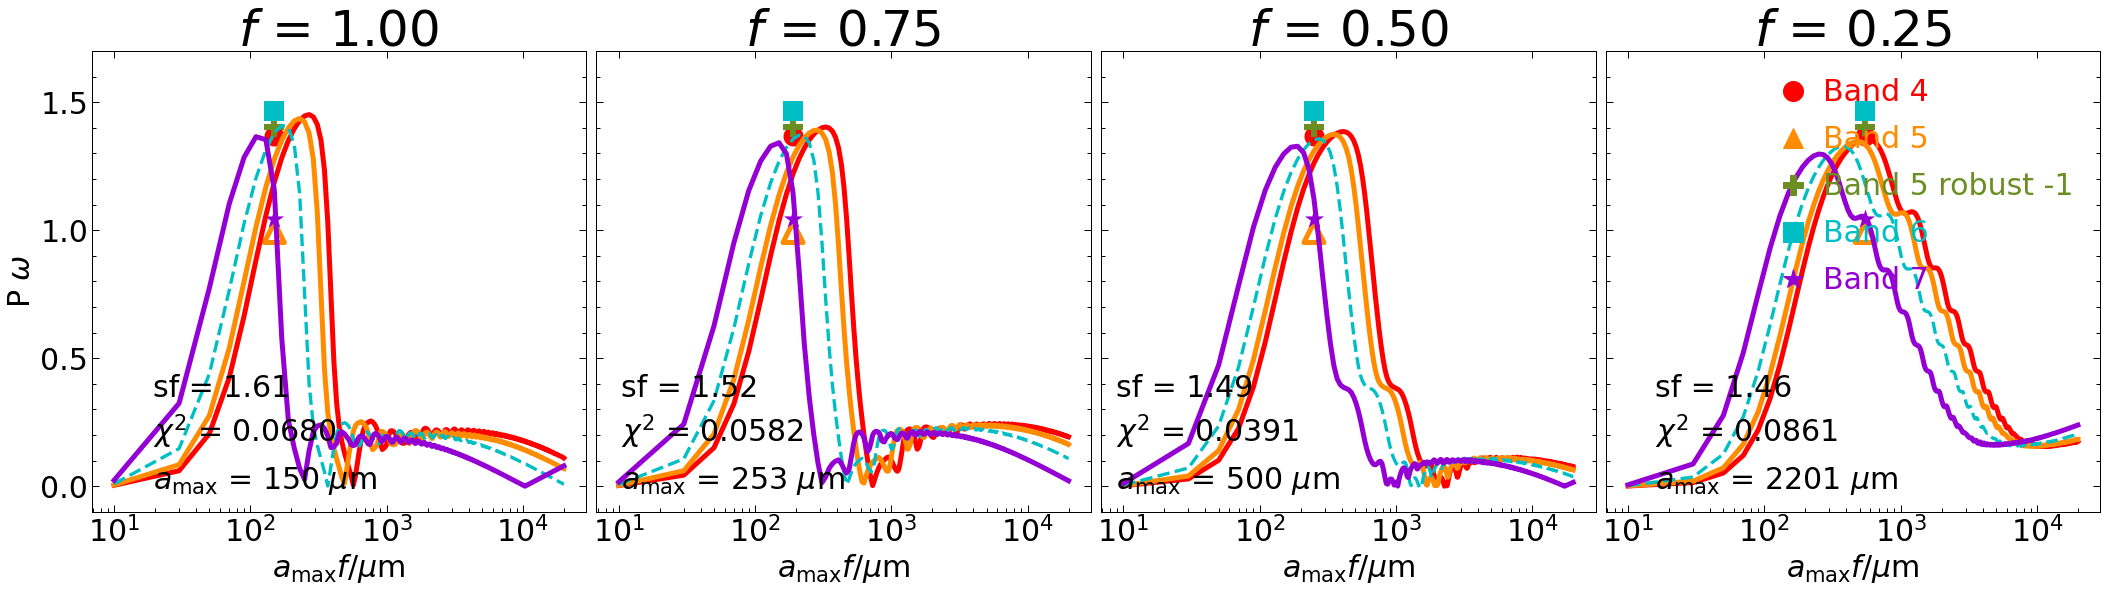

In [24]:
fig, ax = plot_scale_factor_results(all_bands, 
                                    bands_labels, 
                                    bands_wo6, 
                                    f_values,                               
                                    a_max_times_f_dist_micron_wo6, 
                                    P_times_omega_wo6,
                                    best_sf_wo6, 
                                    best_idx_wo6,
                                    best_a_max_times_f_wo6, 
                                    POLF_obs_for_plot,
                                    custom_text_x = [0.075, 0, -0.02, 0.05],
                                   chi_sq_precision = 4,
                                   x_axis = 'amax_f')
# Also want to plot Band 6 data 
plt.savefig(writeup_image_folder_path + '/DustModels/' + "DustModelPlot_Without6_amaxf.pdf", 
            dpi=300, 
            bbox_inches='tight')

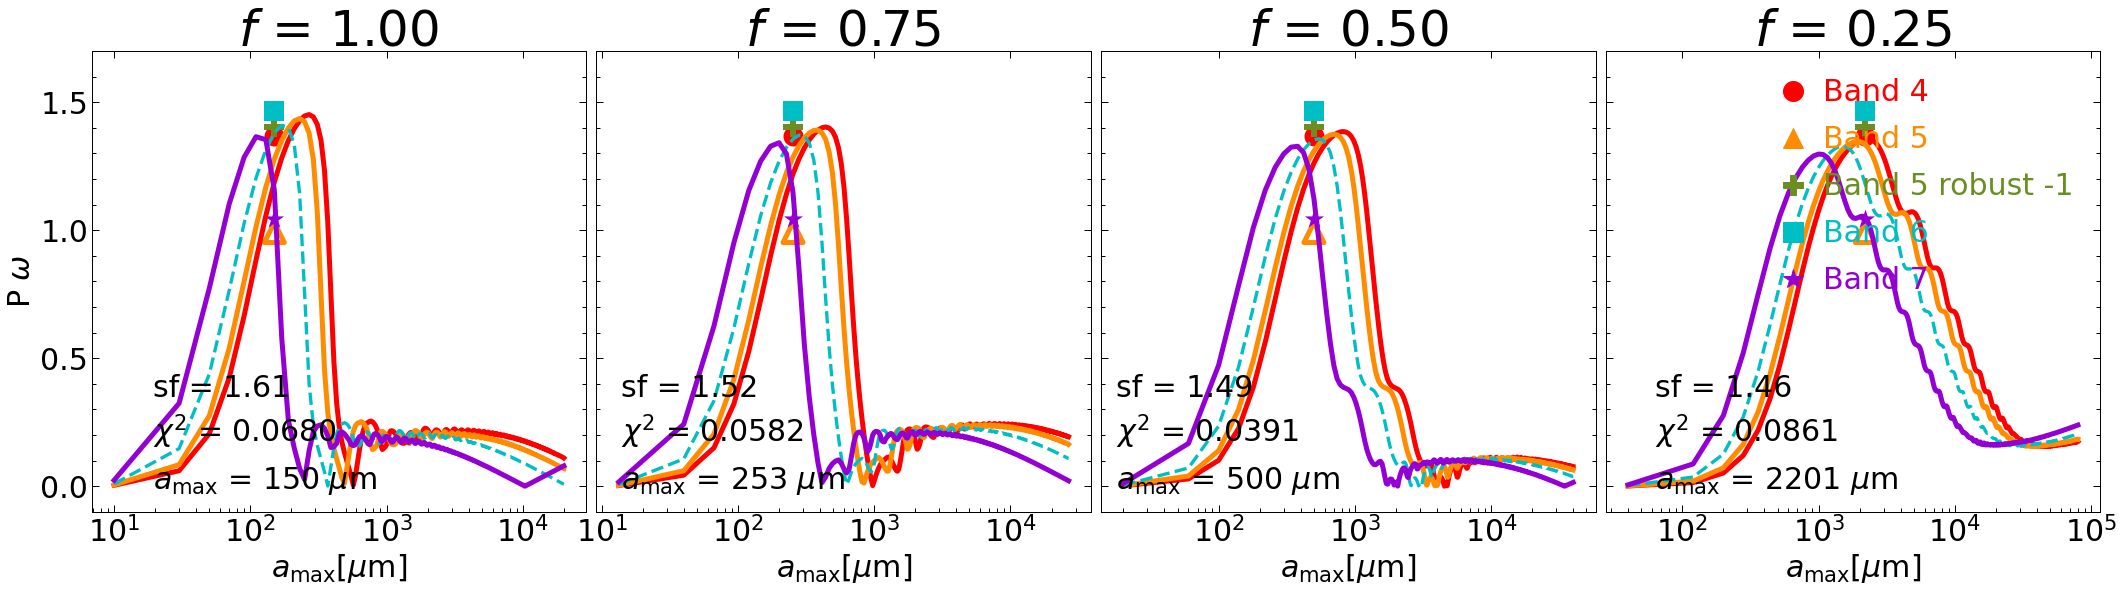

In [25]:
fig, ax = plot_scale_factor_results(all_bands, 
                                    bands_labels, 
                                    bands_wo6, 
                                    f_values,                               
                                    a_max_times_f_dist_micron_wo6, 
                                    P_times_omega_wo6,
                                    best_sf_wo6, 
                                    best_idx_wo6,
                                    best_a_max_times_f_wo6, 
                                    POLF_obs_for_plot,
                                    custom_text_x = [0.075, 0, -0.02, 0.05],
                                   chi_sq_precision = 4,
                                   x_axis = 'amax')

# Also want to plot Band 6 data 
plt.savefig(writeup_image_folder_path + '/DustModels/' + "DustModelPlot_Without6.pdf", 
            dpi=300, 
            bbox_inches='tight')

# Just 4 and 7

In [26]:
bands_just_47 = ["Band 4 nterms2",   "Band 7 nterms2"]


a_max_times_f_dist_micron_just_47, P_times_omega_just_47, best_a_max_times_f_just_47, POLF_obs_just_47, best_sf_just_47, best_idx_just_47 = find_sf_v3(
    all_bands,
    bands_naming,
    bands_just_47,
    csv_files,
    P_omega_data_folder_path,
    df_POLF,
    POLF_type,
    trouble = True,
    choose_trouble_index = True
)



The Bands we are looking at are: ['Band 4 nterms2', 'Band 5', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 7 nterms2']
The best a_max_times_f is: 4412.202202202202
At this value, the best sf is : 8.80160857073848
 
The second best a_max_times_f is: 4152.072072072072
At this value, the best sf is : 8.670699675239101
 
The third best a_max_times_f is: 4172.082082082082
At this value, the best sf is : 8.632913330026108
 


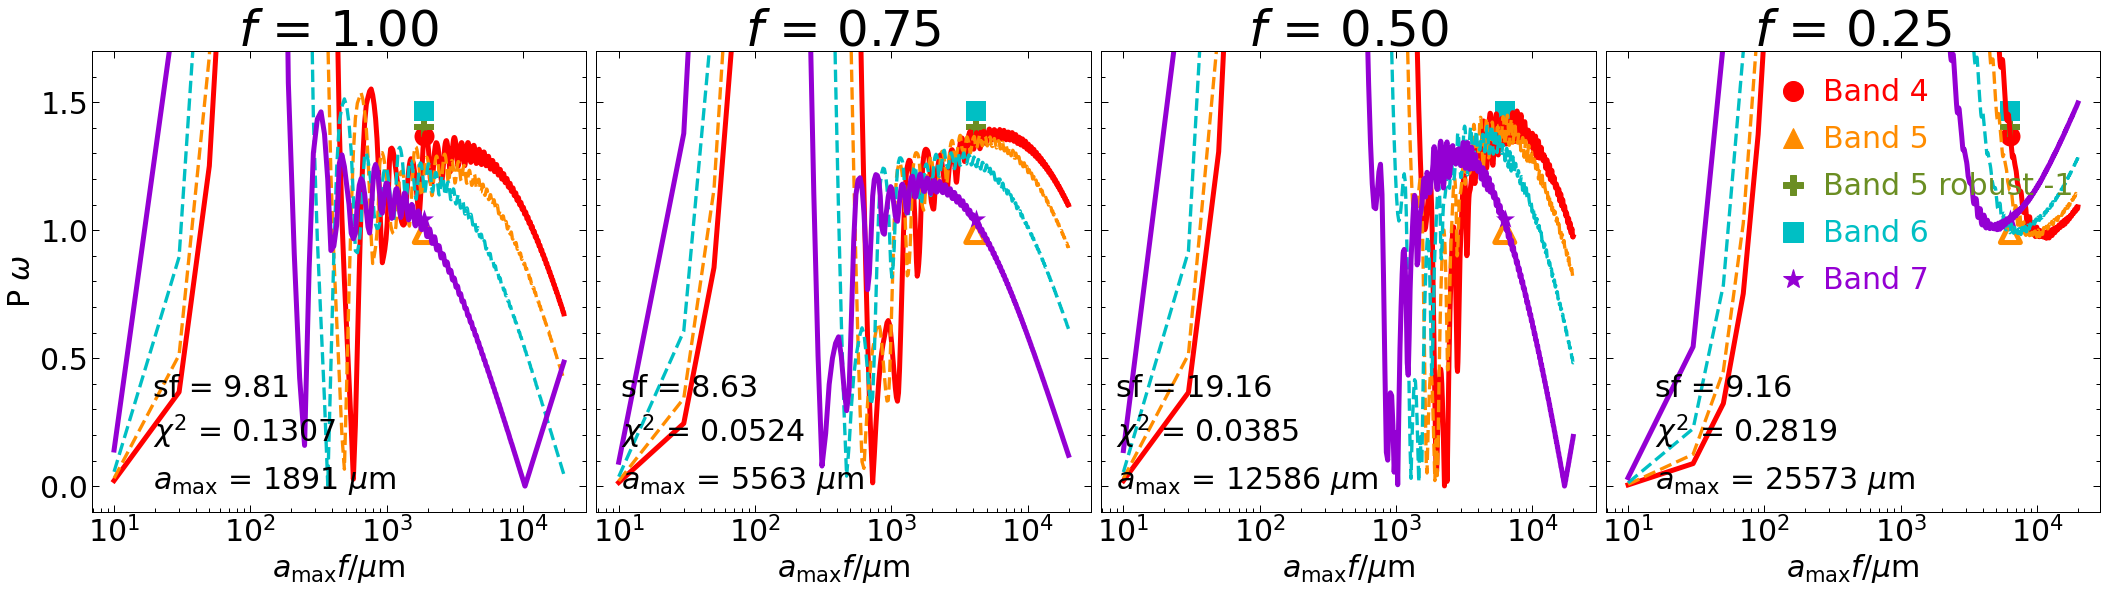

In [27]:
fig, ax = plot_scale_factor_results(all_bands, 
                                    bands_labels, 
                                    bands_just_47, 
                                    f_values,                               
                                    a_max_times_f_dist_micron_just_47, 
                                    P_times_omega_just_47,
                                    best_sf_just_47, 
                                    best_idx_just_47,
                                    best_a_max_times_f_just_47, 
                                    POLF_obs_for_plot,
                                    custom_text_x = [0.075, 0, -0.02, 0.05],
                                   chi_sq_precision = 4,
                                   x_axis = 'amax_f')
    



plt.savefig(writeup_image_folder_path + '/DustModels/' + "DustModelPlot_Just47_amaxf.pdf", 
            dpi=300, 
            bbox_inches='tight')

In [28]:
fig, ax = plot_scale_factor_results(all_bands, 
                                    bands_labels, 
                                    bands_just_47, 
                                    f_values,                               
                                    a_max_f_dist_micron_just_47, 
                                    P_times_omega_just_47,
                                    best_sf_just_47, 
                                    best_idx_just_47,
                                    best_a_max_f_just_47, 
                                    POLF_obs_for_plot,
                                    custom_text_x = [0.075, 0, -0.02, 0.05],
                                   chi_sq_precision = 4,
                                   x_axis = 'amax')


plt.savefig(writeup_image_folder_path + '/DustModels/' + "DustModelPlot_Just47.pdf", 
            dpi=300, 
            bbox_inches='tight')

NameError: name 'a_max_f_dist_micron_just_47' is not defined